# Pertanyaan Bisnis
  * Bagaimana pengaruh variabel cuaca ekstrem dan musim terhadap ketersediaan armada serta manajemen logistik sepeda?
  * Apa perbedaan pola perilaku antara pengguna Casual dan Registered, dan bagaimana strategi konversi yang tepat untuk meningkatkan loyalitas?

# Sumber Dataset

Fanaee-T, Hadi, and Gama, Joao, "Event labeling combining ensemble detectors and background knowledge", Progress in Artificial Intelligence (2013): pp. 1-15, Springer Berlin Heidelberg, doi:10.1007/s13748-013-0040-3.

## Import Library

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Understanding

In [70]:
BASE = '/kaggle/input/datasets/nailasya/bike-sharing/'

df_day = pd.read_csv(BASE + 'day.csv')
df_hour = pd.read_csv(BASE + 'hour.csv')

print(df_day.head())
print(df_hour.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

### Day

In [71]:
df_day.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [72]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [73]:
missing_summary = df_day.isnull().sum()
print(missing_summary)

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [74]:
print("Jumlah duplikasi: "), df_day.duplicated().sum()

Jumlah duplikasi: 


(None, np.int64(0))

In [75]:
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Hour

In [76]:
df_hour.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [77]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [78]:
missing_summary = df_hour.isnull().sum()
print(missing_summary)

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [79]:
print("Jumlah duplikasi: "), df_hour.duplicated().sum()

Jumlah duplikasi: 


(None, np.int64(0))

In [80]:
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## Data Preprocessing

### Day

In [81]:
datetime_columns = ["dteday"]
for column in datetime_columns:
    df_day[column] = pd.to_datetime(df_day[column])

In [82]:
cols_to_category = ['holiday', 'workingday']
for col in cols_to_category:
    df_day[col] = df_day[col].astype('category')

In [83]:
print(df_day.head())

   instant     dteday  season  yr  mnth holiday  weekday workingday  \
0        1 2011-01-01       1   0     1       0        6          0   
1        2 2011-01-02       1   0     1       0        0          0   
2        3 2011-01-03       1   0     1       0        1          1   
3        4 2011-01-04       1   0     1       0        2          1   
4        5 2011-01-05       1   0     1       0        3          1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


In [84]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(2), datetime64

### Hour

In [85]:
datetime_columns = ["dteday"]
for column in datetime_columns:
    df_hour[column] = pd.to_datetime(df_hour[column])

In [86]:
cols_to_category = ['yr', 'hr', 'holiday', 'workingday']
for col in cols_to_category:
    df_hour[col] = df_hour[col].astype('category')

In [87]:
print(df_hour.head())

   instant     dteday  season yr  mnth hr holiday  weekday workingday  \
0        1 2011-01-01       1  0     1  0       0        6          0   
1        2 2011-01-01       1  0     1  1       0        6          0   
2        3 2011-01-01       1  0     1  2       0        6          0   
3        4 2011-01-01       1  0     1  3       0        6          0   
4        5 2011-01-01       1  0     1  4       0        6          0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


In [88]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  category      
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

## Exploratory Data Analysis (EDA)

### Day

In [89]:
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
}
df_day['weathersit'] = df_day['weathersit'].map(weather_mapping)

In [90]:
# Mapping untuk kolom Season
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df_day['season'] = df_day['season'].map(season_mapping)

In [91]:
# Mapping untuk kolom weekday
weekday_mapping ={0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
df_day['weekday'] = df_day['weekday'].map(weekday_mapping)

In [92]:
# Mapping untuk kolom 'mnth'
month_mapping = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
df_day['mnth'] = df_day['mnth'].map(month_mapping)

### Hour

In [93]:
# Mapping untuk kolom Season
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df_hour['season'] = df_hour['season'].map(season_mapping)

In [94]:
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
}
df_hour['weathersit'] = df_hour['weathersit'].map(weather_mapping)

In [95]:
# Mapping untuk kolom weekday
weekday_mapping ={0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
df_hour['weekday'] = df_hour['weekday'].map(weekday_mapping)

In [96]:
# Mapping untuk kolom 'mnth'
month_mapping = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
df_hour['mnth'] = df_hour['mnth'].map(month_mapping)

### EDA Untuk Pertanyaan Bisnis 1

In [97]:
# EDA 1: Mengelompokkan penyewaan berdasarkan Musim
print("--- Rata-rata Penyewaan per Musim ---")
print(df_day.groupby('season')['cnt'].mean().sort_values(ascending=False))
print("\n")

--- Rata-rata Penyewaan per Musim ---
season
Fall      5644.303191
Summer    4992.331522
Winter    4728.162921
Spring    2604.132597
Name: cnt, dtype: float64




In [98]:
# EDA 2: Mengelompokkan penyewaan berdasarkan Kondisi Cuaca
print("--- Rata-rata Penyewaan per Kondisi Cuaca ---")
print(df_day.groupby('weathersit')['cnt'].mean().sort_values(ascending=False))
print("\n")

--- Rata-rata Penyewaan per Kondisi Cuaca ---
weathersit
Clear/Partly Cloudy    4876.786177
Misty/Cloudy           4035.862348
Light Snow/Rain        1803.285714
Name: cnt, dtype: float64




In [99]:
# EDA 3: Korelasi antara Suhu, Kelembapan, dan Kecepatan Angin terhadap Total Penyewaan
correlation = df_day[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
print("--- Korelasi Variabel Cuaca terhadap Jumlah Penyewaan ---")
print(correlation['cnt'].sort_values(ascending=False))

--- Korelasi Variabel Cuaca terhadap Jumlah Penyewaan ---
cnt          1.000000
atemp        0.631066
temp         0.627494
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64


### EDA Untuk Pertanyaan Bisnis 2

In [100]:
# EDA 4: Perbandingan Casual vs Registered di Hari Kerja vs Hari Libur
user_stats = df_day.groupby('workingday').agg({
    'casual': ['mean', 'std', 'max'],
    'registered': ['mean', 'std', 'max'],
    'cnt': ['mean']
})
print("--- Statistik Pengguna Berdasarkan Hari Kerja (1) vs Hari Libur (0) ---")
print(user_stats)
print("\n")

--- Statistik Pengguna Berdasarkan Hari Kerja (1) vs Hari Libur (0) ---
                 casual                     registered                     \
                   mean         std   max         mean          std   max   
workingday                                                                  
0           1371.134199  873.064794  3410  2959.034632  1293.867686  5966   
1            606.570000  391.496032  2469  3978.250000  1568.692453  6946   

                    cnt  
                   mean  
workingday               
0           4330.168831  
1           4584.820000  




/tmp/ipykernel_58/690808537.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_stats = df_day.groupby('workingday').agg({


In [101]:
# EDA 5: Mencari hari dengan jumlah penyewaan tertinggi untuk pengguna Casual
top_casual_days = df_day.sort_values(by='casual', ascending=False).head(5)
print("--- 5 Hari dengan Penyewaan Casual Tertinggi ---")
print(top_casual_days[['dteday', 'workingday', 'casual', 'cnt']])

--- 5 Hari dengan Penyewaan Casual Tertinggi ---
        dteday workingday  casual   cnt
504 2012-05-19          0    3410  8294
512 2012-05-27          0    3283  6591
462 2012-04-07          0    3252  6857
623 2012-09-15          0    3160  8714
441 2012-03-17          0    3155  7836


In [102]:
# Melihat rangkuman statistik untuk seluruh dataset numerik
print("--- Rangkuman Statistik Dataset ---")
print(df_day.describe())

--- Rangkuman Statistik Dataset ---
          instant               dteday          yr        temp       atemp  \
count  731.000000                  731  731.000000  731.000000  731.000000   
mean   366.000000  2012-01-01 00:00:00    0.500684    0.495385    0.474354   
min      1.000000  2011-01-01 00:00:00    0.000000    0.059130    0.079070   
25%    183.500000  2011-07-02 12:00:00    0.000000    0.337083    0.337842   
50%    366.000000  2012-01-01 00:00:00    1.000000    0.498333    0.486733   
75%    548.500000  2012-07-01 12:00:00    1.000000    0.655417    0.608602   
max    731.000000  2012-12-31 00:00:00    1.000000    0.861667    0.840896   
std    211.165812                  NaN    0.500342    0.183051    0.162961   

              hum   windspeed       casual   registered          cnt  
count  731.000000  731.000000   731.000000   731.000000   731.000000  
mean     0.627894    0.190486   848.176471  3656.172367  4504.348837  
min      0.000000    0.022392     2.000000    20

## Visualisasi

Analisis Musiman & Cuaca

/tmp/ipykernel_58/4166033753.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_day, x='season', y='cnt', ax=ax[0], palette='viridis', errorbar=None)
/tmp/ipykernel_58/4166033753.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_day, x='weathersit', y='cnt', ax=ax[1], palette='magma', errorbar=None)


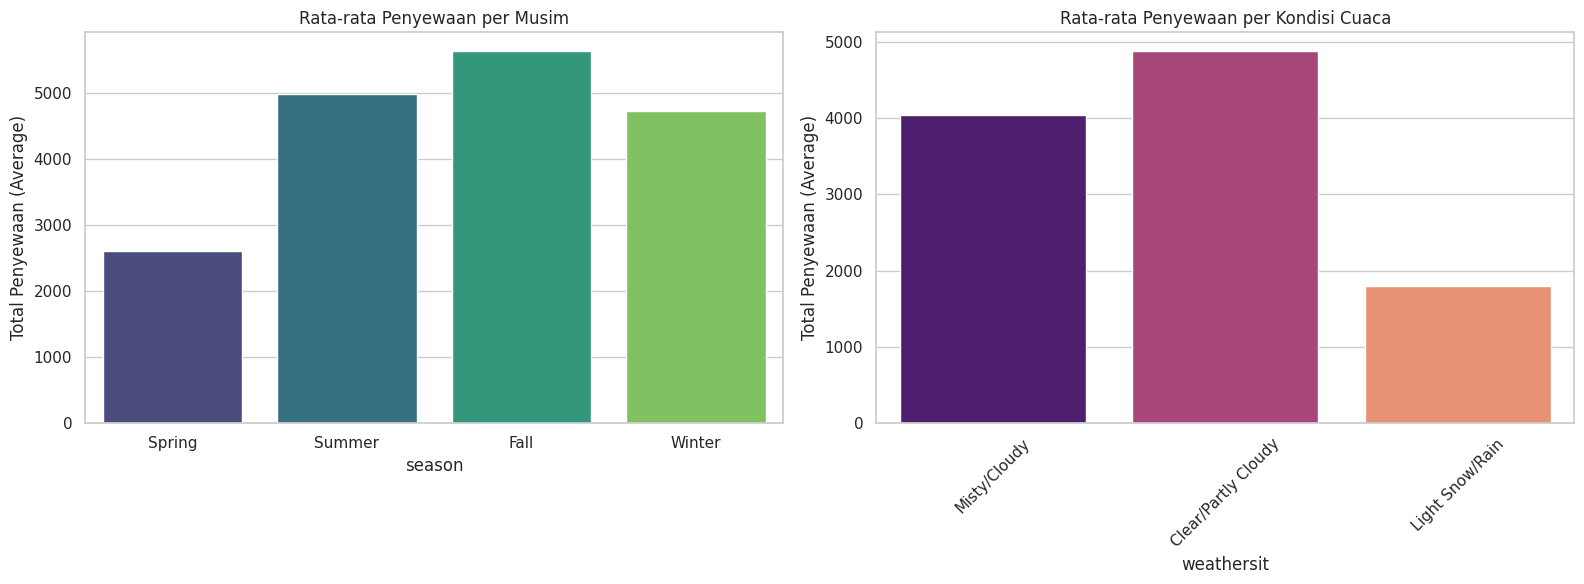

In [103]:
sns.set_theme(style="whitegrid")

# --- 1. Analisis Musiman & Cuaca ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Bar Chart: Rata-rata penyewaan per Musim
sns.barplot(data=df_day, x='season', y='cnt', ax=ax[0], palette='viridis', errorbar=None)
ax[0].set_title('Rata-rata Penyewaan per Musim')
ax[0].set_ylabel('Total Penyewaan (Average)')

# Bar Chart: Rata-rata penyewaan per Kondisi Cuaca
sns.barplot(data=df_day, x='weathersit', y='cnt', ax=ax[1], palette='magma', errorbar=None)
ax[1].set_title('Rata-rata Penyewaan per Kondisi Cuaca')
ax[1].set_ylabel('Total Penyewaan (Average)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

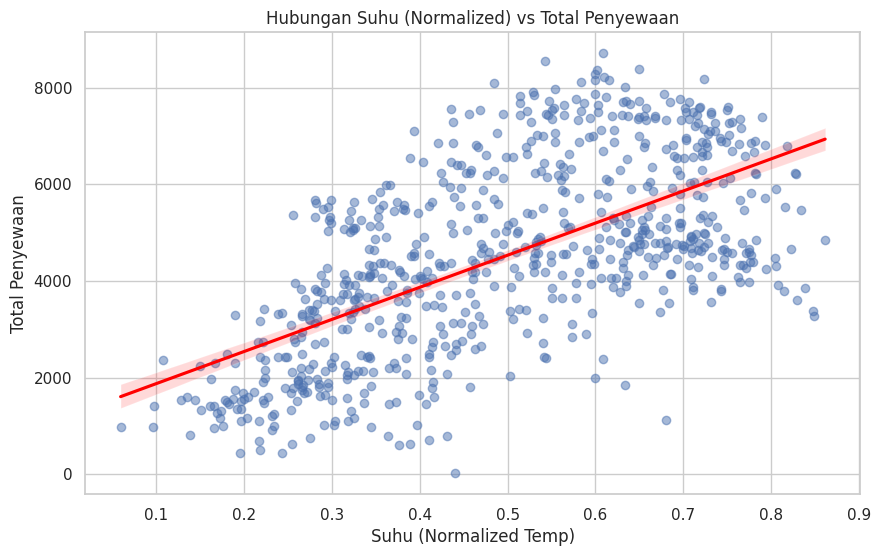

In [104]:
# --- 2. Hubungan Suhu dengan Penyewaan (Scatter Plot) ---
plt.figure(figsize=(10, 6))
sns.regplot(data=df_day, x='temp', y='cnt', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Hubungan Suhu (Normalized) vs Total Penyewaan')
plt.xlabel('Suhu (Normalized Temp)')
plt.ylabel('Total Penyewaan')
plt.show()

/tmp/ipykernel_58/2862127027.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_behavior = df_day.groupby('workingday')[['casual', 'registered']].mean().reset_index()


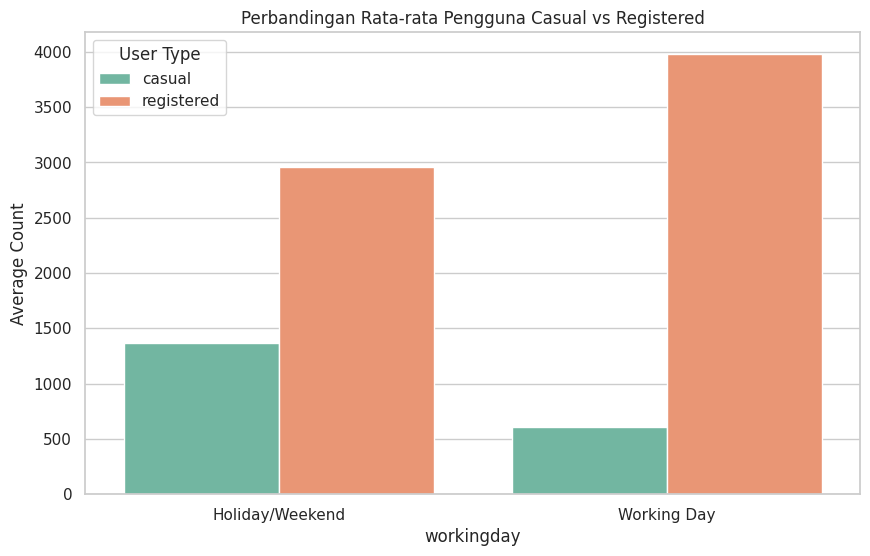

In [105]:
# --- 3. Analisis Perilaku Pengguna (Casual vs Registered) ---
# Kita perlu melakukan sedikit manipulasi data (melt) agar mudah dibandingkan dalam satu plot
user_behavior = df_day.groupby('workingday')[['casual', 'registered']].mean().reset_index()
user_behavior['workingday'] = user_behavior['workingday'].map({0: 'Holiday/Weekend', 1: 'Working Day'})
# Melebur data agar bisa dipisahkan dengan warna (hue)
user_behavior_melted = user_behavior.melt(id_vars='workingday', var_name='User Type', value_name='Average Count')

plt.figure(figsize=(10, 6))
sns.barplot(data=user_behavior_melted, x='workingday', y='Average Count', hue='User Type', palette='Set2')
plt.title('Perbandingan Rata-rata Pengguna Casual vs Registered')
plt.show()

## Analisis Lanjutan

### RFM

In [108]:
# Menentukan tanggal referensi (hari terakhir di dataset)
recent_date = df_day['dteday'].max()

# Membuat dataframe RFM berdasarkan tanggal (dteday)
rfm_df = df_day.groupby(by="dteday", as_index=False).agg({
    "cnt": "sum"
    })

# Menghitung Recency (selisih hari dari tanggal terakhir)
rfm_df["recency"] = (recent_date - rfm_df["dteday"]).dt.days

# Kita ambil 10 hari dengan penyewaan tertinggi (High Value Days)
rfm_df.columns = ["dteday", "monetary", "recency"]
print("--- Top 5 High Value Days (Berdasarkan Monetary) ---")
print(rfm_df.sort_values(by="monetary", ascending=False).head())

--- Top 5 High Value Days (Berdasarkan Monetary) ---
        dteday  monetary  recency
623 2012-09-15      8714      107
637 2012-09-29      8555       93
630 2012-09-22      8395      100
447 2012-03-23      8362      283
504 2012-05-19      8294      226


### Clustering

In [109]:
bins = [0, 2000, 5000, df_day['cnt'].max()]
labels = ['Low Demand', 'Medium Demand', 'High Demand']

df_day['demand_category'] = pd.cut(df_day['cnt'], bins=bins, labels=labels)

# Melihat distribusi cluster
demand_summary = df_day.groupby('demand_category')['cnt'].count().reset_index()
print("--- Distribusi Cluster Kategori Permintaan ---")
print(demand_summary)

# Analisis lanjutan: Di musim apa 'High Demand' paling sering terjadi?
high_demand_season = df_day[df_day['demand_category'] == 'High Demand'].groupby('season').size()
print("\n--- Kemunculan High Demand per Musim ---")
print(high_demand_season)

--- Distribusi Cluster Kategori Permintaan ---
  demand_category  cnt
0      Low Demand   98
1   Medium Demand  347
2     High Demand  286

--- Kemunculan High Demand per Musim ---
season
Fall      109
Spring     10
Summer     87
Winter     80
dtype: int64


/tmp/ipykernel_58/387919405.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demand_summary = df_day.groupby('demand_category')['cnt'].count().reset_index()
